# EDGAR Credit Clustering v3 — Clean src-driven notebook

This notebook is intentionally thin. It orchestrates the workflow and delegates reusable logic to `src.credit_clustering`:

- EDGAR concept/SIC mapping: `edgar_concepts.py`
- Feature engineering: `features.py`
- Clustering: `clustering.py`
- Cluster profiling: `profiling.py`
- Artifact building/saving: `artifacts.py`

The notebook should not define reusable methods.

In [1]:
import os
import sys
from pathlib import Path

from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

pd.set_option("display.max_rows", 300)
pd.set_option("display.max_columns", 160)
pd.set_option("display.max_colwidth", 160)

In [2]:
BASE_URL = "https://pub-a6c3a3e1a0f546beb4be7cc34fd647d1.r2.dev/raw_financial_facts_parquet"

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

DUCKDB_DIR = PROJECT_ROOT / "data" / "duckdb"
DUCKDB_DIR.mkdir(parents=True, exist_ok=True)

DB_PATH = DUCKDB_DIR / "financials.duckdb"

OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

MODEL_DIR = OUTPUT_DIR / "saved_models"
MODEL_DIR.mkdir(exist_ok=True)

CURRENT_OUTPUT_DIR = OUTPUT_DIR / "credit_clustering_outputs_v3"
CURRENT_OUTPUT_DIR.mkdir(exist_ok=True)

ARTIFACT_PATH = MODEL_DIR / "nonfinancial_credit_scorecard_kmeans_k5_v3.joblib"

In [3]:
#Import your modules here

from src.credit_clustering import (
    # Config
    PUBLIC_COMPANY_MIN_ASSETS,
    SCORECARD_CLUSTER_FEATURES,
    SCORECARD_COMPONENT_FEATURES,
    RATIO_COLS,
    INTERPRET_FEATURES,
    DEFAULT_SEGMENT_COL,
    DEFAULT_TARGET_SEGMENTS,
    DEFAULT_N_CLUSTERS,
    DEFAULT_MIN_ROWS_PER_SEGMENT,
    cluster_segments,

    # EDGAR concepts and panel construction
    EDGAR_CONCEPT_MAP,
    create_issuer_year_facts_table,
    build_issuer_year_panel,

    # Feature engineering
    engineer_private_company_features,

    # Clustering
    cluster_segments,
    evaluate_segments_k_range,

    # Profiling
    build_cluster_profile,
    build_cluster_medians,
    build_feature_extremes,
    build_industry_cluster_mix,
    add_rating_style_labels,
    build_rating_label_maps,
    representatives,
    merge_profile_with_representatives,

    # Artifacts
    build_credit_clustering_artifact,
    save_artifact,
    summarize_artifact,

    #Config settings
    DEFAULT_N_CLUSTERS,
    DEFAULT_RANDOM_STATE,
    DEFAULT_N_INIT,
)

## 1. Connect to EDGAR raw facts

The raw EDGAR-derived facts are read from remote Parquet files into a DuckDB view.

In [4]:
parquet_urls = [
    f"{BASE_URL}/part_{i:05d}.parquet"
    for i in range(401)
]

con = duckdb.connect(DB_PATH)

con.execute("""
INSTALL httpfs;
LOAD httpfs;
""")

con.execute(f"""
CREATE OR REPLACE VIEW raw_facts AS
SELECT *
FROM read_parquet({parquet_urls})
""")

schema = con.execute("DESCRIBE raw_facts").df()
schema.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,column_name,column_type,null,key,default,extra
0,concept,VARCHAR,YES,None,None,None
1,label,VARCHAR,YES,None,None,None
2,value,DOUBLE,YES,None,None,None
3,numeric_value,DOUBLE,YES,None,None,None
4,unit,VARCHAR,YES,None,None,None


In [5]:
#Optional: Inspect the whole existing database. Attention this is will call the database and
#take close to or over 1 minute. It is not needed downstream. 
RUN_RAW_DATABASE_AUDIT = False

if RUN_RAW_DATABASE_AUDIT:
    raw_summary = con.execute("""
    SELECT
        COUNT(*) AS rows,
        COUNT(DISTINCT ticker) AS tickers,
        COUNT(DISTINCT concept) AS concepts,
        MIN(fiscal_year) AS min_year,
        MAX(fiscal_year) AS max_year
    FROM raw_facts
    """).df()

    display(raw_summary)

## 2. Build issuer-year facts and panel

The EDGAR concept map lives in `src.credit_clustering.edgar_concepts`. The notebook only calls the extraction helpers.

In [7]:
facts_summary, value_col, sort_col = create_issuer_year_facts_table(
    con=con,
    schema=schema,
    concept_map=EDGAR_CONCEPT_MAP,
    start_year=2020,
    end_year=2025,
    fiscal_period="FY",
)

print("value_col:", value_col, "| sort_col:", sort_col)
display(facts_summary)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

value_col: numeric_value | sort_col: period_end


,canonical_feature,row_count,ticker_count
0,net_income,36055,7171
1,assets,36044,7147
2,cfo,35527,7106
3,equity,35594,7048
4,cash,34942,7035
5,depreciation_amortization,31723,6491
6,liabilities,31638,6462
7,revenue,27296,5841
8,operating_income,27902,5778
9,ppe,26720,5771


In [8]:
panel = build_issuer_year_panel(
    con=con,
    concept_map=EDGAR_CONCEPT_MAP,
)

print("Panel shape:", panel.shape)
display(panel.head())

Panel shape: (36290, 29)


,ticker,cik,company_name,sic,fiscal_year,assets,assets_current,capex,cash,cfo,depreciation_amortization,equity,goodwill,gross_profit,interest_expense,inventory,liabilities,liabilities_current,long_term_debt,net_income,operating_income,ppe,rd,receivables,revenue,sga,short_term_debt,major_sector,financial_flag
0,VABK,1572334,Virginia National Bankshares Corp,6021,2021,1.410297e+09,NaN,746000.0,1.423050e+07,1.115900e+07,1.678000e+06,8.259800e+07,7.768000e+06,NaN,3317500.0,NaN,1.288004e+09,NaN,NaN,9.024500e+06,NaN,1.516550e+07,NaN,NaN,NaN,NaN,NaN,Finance / Insurance / Real Estate,Financial
1,WDAY,1327811,"Workday, Inc.",7374,2025,1.721450e+10,1.024200e+10,269000000.0,1.886000e+09,2.149000e+09,2.430000e+08,8.082000e+09,3.162000e+09,NaN,NaN,NaN,8.656500e+09,5.301500e+09,2.982000e+09,5.260000e+08,1.830000e+08,1.236500e+09,2.464000e+09,1.794500e+09,7.259000e+09,NaN,NaN,Services,Non-financial
2,SBEV,1553788,"SPLASH BEVERAGE GROUP, INC.",2080,2023,1.360174e+07,7.317411e+06,NaN,4.181383e+06,-1.211495e+07,3.920680e+05,8.873227e+06,2.568230e+05,5743780.0,1054137.0,2986888.0,1.174333e+07,9.857947e+06,1.496988e+06,-2.134711e+07,-1.834065e+07,4.196995e+05,NaN,1.351370e+06,1.846882e+07,NaN,NaN,Manufacturing / Industrials,Non-financial
3,BATRA,1958140,"Atlanta Braves Holdings, Inc.",7900,2024,1.504330e+09,1.985825e+08,NaN,1.377170e+08,1.663100e+07,5.926450e+07,5.263880e+08,1.757640e+08,NaN,NaN,NaN,9.756550e+08,2.601665e+08,5.481925e+08,-3.417200e+07,-3.966500e+07,7.871160e+08,NaN,2.773300e+07,6.406670e+08,124902000.0,73173000.0,Services,Non-financial
4,ED,1047862,CONSOLIDATED EDISON INC,4931,2023,6.633100e+10,9.754500e+09,NaN,1.238500e+09,2.733000e+09,2.031000e+09,2.078800e+10,4.080000e+08,NaN,905000000.0,NaN,NaN,8.899000e+09,2.233950e+10,1.630000e+09,2.826000e+09,4.818700e+10,NaN,2.305000e+09,1.456950e+10,NaN,626500000.0,Transportation / Utilities,Non-financial


In [9]:
panel.groupby(["major_sector", "fiscal_year"]).size().unstack(fill_value=0)

fiscal_year,2020,2021,2022,2023,2024,2025
major_sector,,,,,,
Agriculture,23,33,38,42,42,34
Construction,53,62,66,70,76,80
Finance / Insurance / Real Estate,1441,1522,1582,1621,1654,1663
Manufacturing / Industrials,1830,2099,2237,2297,2365,2253
Mining / Energy,213,225,248,254,246,239
Services,875,1060,1120,1156,1228,1187
Transportation / Utilities,425,450,470,470,487,479
Wholesale / Retail,326,378,388,400,410,373


## 3. Engineer credit scorecard features

Feature construction is centralized in `features.py` so training and private-company scoring use the same logic.

In [10]:
model_df = engineer_private_company_features(
    panel,
    winsor_caps=None,
    fx_to_model_currency=1.0,
)

# Training/reference universe filter.
# The threshold is controlled in config.py.
model_df = model_df.loc[
    model_df["assets"].ge(PUBLIC_COMPANY_MIN_ASSETS)
].copy()

print("Model rows:", len(model_df))
display(model_df[SCORECARD_CLUSTER_FEATURES].describe().T)

Model rows: 34299


,count,mean,std,min,25%,50%,75%,max
structural_distress_risk,29673.0,0.485429,0.343572,0.0,0.161540,0.499576,0.815629,1.0
earnings_risk,34117.0,0.644533,0.323179,0.0,0.450627,0.639204,1.000000,1.0
operating_cashflow_risk,18887.0,0.622924,0.302695,0.0,0.362742,0.664295,0.904237,1.0
liquidity_risk,13919.0,0.496949,0.271510,0.0,0.250570,0.499625,0.721922,1.0
leverage_risk,6316.0,0.406852,0.263516,0.0,0.196829,0.378539,0.608355,1.0
debt_service_risk,7791.0,0.662562,0.336475,0.0,0.415315,0.781649,0.981353,1.0


In [11]:
feature_availability = (
    model_df[SCORECARD_CLUSTER_FEATURES + SCORECARD_COMPONENT_FEATURES]
    .notna()
    .mean()
    .sort_values(ascending=False)
    .to_frame("availability_pct")
)

feature_availability

,availability_pct
liabilities_exceed_assets_flag,1.000000
negative_equity_flag,1.000000
profitability_risk,0.994694
earnings_risk,0.994694
equity_buffer_risk,0.983323
cashflow_risk,0.981661
cash_buffer_risk,0.970407
liabilities_risk,0.878101
structural_distress_risk,0.865127
current_liquidity_risk,0.755007


## 4. Cluster non-financial issuers

The clustering code lives in `clustering.py`. The model uses bounded directional risk factors, not raw accounting values.

In [12]:
model = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            # ("scaler", RobustScaler()),
            ("cluster", KMeans(
                    n_clusters=DEFAULT_N_CLUSTERS,
                    init="k-means++",
                    n_init=DEFAULT_N_INIT,
                    random_state=DEFAULT_RANDOM_STATE,
                    verbose=False),
            ),
        ])

model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('cluster', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account f

In [13]:
clustered_panel, metrics_df, segment_artifacts = cluster_segments(
    model_df,
    model=model,
    segment_col=DEFAULT_SEGMENT_COL,
    min_rows=DEFAULT_MIN_ROWS_PER_SEGMENT,
    cluster_only_segments=DEFAULT_TARGET_SEGMENTS,
)

print("Clustered rows:", len(clustered_panel))
display(metrics_df)

Clustered rows: 12174


,segment,status,rows,features,feature_list,silhouette,calinski_harabasz,davies_bouldin,feature_availability,min_non_null_features
0,Financial,skipped_not_target_segment,9271,0,[],NaN,NaN,NaN,NaN,NaN
1,Non-financial,clustered,12174,6,"[earnings_risk, structural_distress_risk, operating_cashflow_risk, liquidity_risk, debt_service_risk, leverage_risk]",0.263323,4862.60908,1.325299,"{'earnings_risk': 0.9956448777369347, 'structural_distress_risk': 0.8307895157423686, 'operating_cashflow_risk': 0.5481061211443183, 'liquidity_risk': 0.528...",4.0


In [14]:
cluster_sizes = (
    clustered_panel
    .groupby([DEFAULT_SEGMENT_COL, "cluster"])
    .size()
    .reset_index(name="issuer_years")
    .sort_values([DEFAULT_SEGMENT_COL, "cluster"])
)

cluster_sizes

,financial_flag,cluster,issuer_years
0,Non-financial,0,2714
1,Non-financial,1,2048
2,Non-financial,2,3418
3,Non-financial,3,2354
4,Non-financial,4,1640


## 5. Build cluster profiles and rating-style labels

The interpretation layer lives in `profiling.py`.

In [15]:
cluster_profile = build_cluster_profile(
    clustered_panel,
    segment_col=DEFAULT_SEGMENT_COL,
)

cluster_medians = build_cluster_medians(
    clustered_panel,
    segment_col=DEFAULT_SEGMENT_COL,
)

feature_extremes = build_feature_extremes(
    clustered_panel,
)

industry_cluster_mix = build_industry_cluster_mix(
    clustered_panel,
    segment_col=DEFAULT_SEGMENT_COL,
)

cluster_profile_ranked = add_rating_style_labels(
    cluster_profile,
    segment_col=DEFAULT_SEGMENT_COL,
)

rating_labels_by_cluster, risk_rank_by_cluster = build_rating_label_maps(
    cluster_profile_ranked,
    segment_name="Non-financial",
    segment_col=DEFAULT_SEGMENT_COL,
)

cluster_representatives = representatives(
    clustered_panel,
    segment_col=DEFAULT_SEGMENT_COL,
)

cluster_profile_ranked_with_reps = merge_profile_with_representatives(
    cluster_profile_ranked,
    cluster_representatives,
    segment_col=DEFAULT_SEGMENT_COL,
)

display(cluster_profile_ranked_with_reps)

,financial_flag,cluster,issuer_years,issuers,median_log_assets,median_liabilities_to_assets,median_debt_to_assets,median_debt_to_equity,median_equity_to_assets,median_cash_to_assets,median_net_income_to_assets,median_cfo_to_assets,median_revenue_to_assets,median_current_ratio,median_quick_ratio,median_interest_coverage,median_fcf_to_debt,median_operating_margin,median_gross_margin,median_ebitda_margin,median_debt_to_ebitda,median_net_debt_to_ebitda,median_ebitda_interest_coverage,median_leverage_risk,median_liquidity_risk,median_earnings_risk,median_operating_cashflow_risk,median_debt_service_risk,median_structural_distress_risk,median_scorecard_credit_score,rating_style_rank,rating_style_label,representative_tickers,sample_companies,sample_years
0,Non-financial,4,1640,639,21.850772,0.509007,0.151957,0.317343,0.431525,0.087512,0.076847,0.119075,0.741405,1.783857,0.857948,14.273972,0.596364,0.142820,0.366556,0.177532,1.183598,0.370943,17.835574,0.218323,0.377506,0.154353,0.207244,0.108311,0.331364,21.236755,1,1 - Strong relative credit profile,"MOD, NIU, KAI, HSIC, CHD, DIT, ANF, NSP, RLGT, NDSN",MODINE MANUFACTURING CO | Niu Technologies | KADANT INC | HENRY SCHEIN INC | CHURCH & DWIGHT CO INC /DE/,"2025, 2020, 2022, 2021, 2023"
1,Non-financial,1,2048,874,21.452476,0.457249,0.164330,0.327429,0.496103,0.101109,0.042854,0.094824,0.601971,2.191861,1.178394,2.724638,0.410472,0.095949,0.361872,0.139333,2.024032,0.710996,5.262654,0.193328,0.264219,0.380970,0.290314,0.576763,0.235404,31.944571,2,2 - Good credit profile,"WWD, THRM, SITE, VIOT, BIDU, BAIDF, AIN, HLIO, WIMI","Woodward, Inc. | Gentherm Inc | SiteOne Landscape Supply, Inc. | Viomi Technology Co., Ltd | Baidu, Inc.","2022, 2024, 2025, 2021, 2020"
2,Non-financial,2,3418,1206,22.500720,0.699943,0.370085,1.080044,0.278083,0.036200,0.024722,0.064899,0.414955,1.117570,0.464281,2.358570,0.128045,0.118983,0.316486,0.182689,5.024903,4.296124,3.889554,0.576082,0.671487,0.501852,0.609693,0.759662,0.595627,60.254576,3,3 - Leveraged / elevated risk profile,"BYD, HPE, HPE-PC, WHR-PA, WHR, XPO, CMRE-PD, CMRE-PB, CMRE, CMRE-PC","BOYD GAMING CORP | Hewlett Packard Enterprise Co | WHIRLPOOL CORP /DE/ | XPO, Inc. | Costamare Inc.","2021, 2025, 2020"
3,Non-financial,0,2714,1116,19.366655,0.414911,0.140877,0.253364,0.513608,0.178877,-0.152602,-0.084680,0.324600,2.975381,1.515642,-14.177290,-0.972332,-0.327905,0.352504,-0.266930,8.340862,5.211459,-11.950707,0.422658,0.260315,1.000000,1.000000,1.000000,0.225017,78.527629,4,4 - Weak credit profile,"URG, IVDA, IVDAW, IONM, ATEC, HOFV, CGON","UR-ENERGY INC | Iveda Solutions, Inc. | Assure Holdings Corp. | Alphatec Holdings, Inc. | Hall of Fame Resort & Entertainment Co","2020, 2022, 2021, 2025, 2023"
4,Non-financial,3,2354,1085,19.158992,0.893757,0.366307,0.271541,0.047054,0.080138,-0.173378,-0.068558,0.516452,0.994785,0.412462,-3.604414,-0.328566,-0.244551,0.277608,-0.191031,11.216977,9.613792,-2.721847,0.785994,0.758301,1.000000,1.000000,1.000000,0.877925,90.203261,5,5 - Distressed / near-default proxy,"FRGT, RDW, VERI, ONDS, HCHL, DDC, IQST, EDBLW, EDBL, MDWK","Freight Technologies, Inc. | Redwire Corp | Veritone, Inc. | Ondas Inc. | Happy City Holdings Ltd","2022, 2023, 2024, 2020, 2025, 2021"


In [16]:
display(cluster_medians)

log_assets  liabilities_to_assets  debt_to_assets  \
financial_flag cluster                                                      
Non-financial  0            19.367                  0.415           0.141   
               1            21.452                  0.457           0.164   
               2            22.501                  0.700           0.370   
               3            19.159                  0.894           0.366   
               4            21.851                  0.509           0.152   

                        debt_to_equity  equity_to_assets  cash_to_assets  \
financial_flag cluster                                                     
Non-financial  0                 0.253             0.514           0.179   
               1                 0.327             0.496           0.101   
               2                 1.080             0.278           0.036   
               3                 0.272             0.047           0.080   
               4                 0.317             0.432           0.088   

                        net_income_to_assets  cfo_to_assets  \
financial_flag cluster                                        
Non-financial  0                      -0.153         -0.085   
               1                       0.043          0.095   
               2                       0.025          0.065   
               3                      -0.173         -0.069   
               4                       0.077          0.119   

                        revenue_to_assets  current_ratio  quick_ratio  \
financial_flag cluster                                                  
Non-financial  0                    0.325          2.975        1.516   
               1                    0.602          2.192        1.178   
               2                    0.415          1.118        0.464   
               3                    0.516          0.995        0.412   
               4                    0.741          1.784        0.858   

                        interest_coverage  fcf_to_debt  operating_margin  \
financial_flag cluster                                                     
Non-financial  0                  -14.177       -0.972            -0.328   
               1                    2.725        0.410             0.096   
               2                    2.359        0.128             0.119   
               3                   -3.604       -0.329            -0.245   
               4                   14.274        0.596             0.143   

                        gross_margin  ebitda_margin  debt_to_ebitda  \
financial_flag cluster                                                
Non-financial  0               0.353         -0.267           8.341   
               1               0.362          0.139           2.024   
               2               0.316          0.183           5.025   
               3               0.278         -0.191          11.217   
               4               0.367          0.178           1.184   

                        net_debt_to_ebitda  ebitda_interest_coverage  \
financial_flag cluster                                                 
Non-financial  0                     5.211                   -11.951   
               1                     0.711                     5.263   
               2                     4.296                     3.890   
               3                     9.614                    -2.722   
               4                     0.371                    17.836   

                        leverage_risk  liquidity_risk  earnings_risk  \
financial_flag cluster                                                 
Non-financial  0                0.423           0.260          1.000   
               1                0.193           0.264          0.381   
               2                0.576           0.671          0.502   
               3                0.786           0.758          1.000   
               4             

In [17]:
display(feature_extremes)

,0.001,0.010,0.050,0.500,0.950,0.990,0.999
log_assets,13.918,14.830,16.266,21.025,25.054,26.030,27.267
liabilities_to_assets,0.034,0.095,0.206,0.601,1.359,3.769,11.154
debt_to_assets,0.000,0.001,0.006,0.241,0.752,1.355,4.997
debt_to_equity,-182.060,-15.319,-1.984,0.449,4.083,19.971,193.940
equity_to_assets,-10.512,-2.710,-0.415,0.347,0.741,0.917,1.141
cash_to_assets,0.000,0.001,0.004,0.082,0.495,0.826,1.126
net_income_to_assets,-7.117,-2.435,-0.828,0.009,0.129,0.233,0.913
cfo_to_assets,-3.212,-1.347,-0.539,0.051,0.183,0.266,0.472
revenue_to_assets,0.000,0.003,0.052,0.493,1.883,3.384,7.317
current_ratio,0.018,0.114,0.442,1.596,6.624,14.390,34.541


In [18]:
display(industry_cluster_mix.head(50))

,financial_flag,cluster,major_sector,row_count,cluster_total,pct_of_cluster
2,Non-financial,0,Manufacturing / Industrials,1700,2714,0.626382
4,Non-financial,0,Services,602,2714,0.221813
5,Non-financial,0,Transportation / Utilities,150,2714,0.055269
6,Non-financial,0,Wholesale / Retail,126,2714,0.046426
3,Non-financial,0,Mining / Energy,92,2714,0.033898
0,Non-financial,0,Agriculture,37,2714,0.013633
1,Non-financial,0,Construction,7,2714,0.002579
9,Non-financial,1,Manufacturing / Industrials,1012,2048,0.494141
11,Non-financial,1,Services,465,2048,0.227051
13,Non-financial,1,Wholesale / Retail,192,2048,0.093750


## 6. Governance check: compare alternative k values

The selected five-cluster model is judged against nearby k alternatives for sanity, not automatic selection.

In [19]:
k_tests = evaluate_segments_k_range(
    df=model_df,
    model=model,
    segment_col=DEFAULT_SEGMENT_COL,
    k_values=range(2, 9),
    cluster_only_segments=DEFAULT_TARGET_SEGMENTS,
    min_rows=DEFAULT_MIN_ROWS_PER_SEGMENT,
)

k_tests

,segment,k,rows,features,feature_list,min_non_null_features,silhouette,calinski_harabasz,davies_bouldin
0,Non-financial,2,12174,6,"[earnings_risk, structural_distress_risk, operating_cashflow_risk, liquidity_risk, debt_service_risk, leverage_risk]",4,0.319395,7014.485533,1.255114
1,Non-financial,3,12174,6,"[earnings_risk, structural_distress_risk, operating_cashflow_risk, liquidity_risk, debt_service_risk, leverage_risk]",4,0.266129,5703.200646,1.296949
2,Non-financial,4,12174,6,"[earnings_risk, structural_distress_risk, operating_cashflow_risk, liquidity_risk, debt_service_risk, leverage_risk]",4,0.256874,5228.317864,1.293833
3,Non-financial,5,12174,6,"[earnings_risk, structural_distress_risk, operating_cashflow_risk, liquidity_risk, debt_service_risk, leverage_risk]",4,0.263323,4862.609080,1.325299
4,Non-financial,6,12174,6,"[earnings_risk, structural_distress_risk, operating_cashflow_risk, liquidity_risk, debt_service_risk, leverage_risk]",4,0.264997,4446.058412,1.384451
5,Non-financial,7,12174,6,"[earnings_risk, structural_distress_risk, operating_cashflow_risk, liquidity_risk, debt_service_risk, leverage_risk]",4,0.261483,4117.684285,1.382273
6,Non-financial,8,12174,6,"[earnings_risk, structural_distress_risk, operating_cashflow_risk, liquidity_risk, debt_service_risk, leverage_risk]",4,0.253943,3903.495022,1.338450


## 7. Dimensionality reduction for cluster visualization

In [20]:
features = segment_artifacts["Non-financial"]["feature_cols"]
fitted_pipeline = segment_artifacts["Non-financial"]["pipeline"]

X_raw = clustered_panel[features]

# Apply all preprocessing steps before the KMeans step
X_prepared = fitted_pipeline[:-1].transform(X_raw)

cluster_labels = clustered_panel["cluster"].to_numpy()

In [21]:
pca_2d = PCA(n_components=2, random_state=DEFAULT_RANDOM_STATE)

X_pca_2d = pca_2d.fit_transform(X_prepared)

pca_2d_df = clustered_panel[
    ["ticker", "company_name", "fiscal_year", DEFAULT_SEGMENT_COL, "cluster"]
].copy()

pca_2d_df["pca_1"] = X_pca_2d[:, 0]
pca_2d_df["pca_2"] = X_pca_2d[:, 1]

print("PCA 2D explained variance ratio:")
print(pca_2d.explained_variance_ratio_)
print("Total explained variance:", pca_2d.explained_variance_ratio_.sum())

PCA 2D explained variance ratio:
[0.50288417 0.23482975]
Total explained variance: 0.7377139221025911


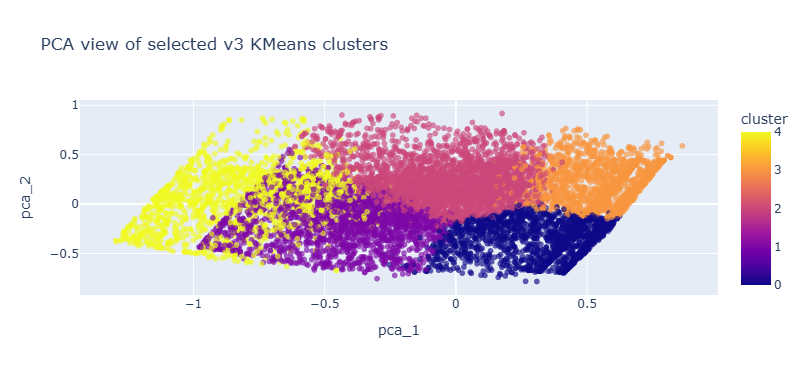

In [22]:
fig = px.scatter(
    pca_2d_df,
    x="pca_1",
    y="pca_2",
    color="cluster",
    title="PCA view of selected v3 KMeans clusters",
    opacity=0.65,
    hover_data=[
        "cluster",
        "company_name",
        "ticker",
        "fiscal_year",
    ],
)


fig.show()

In [23]:
pca_3d = PCA(n_components=3, random_state=DEFAULT_RANDOM_STATE)

X_pca_3d = pca_3d.fit_transform(X_prepared)

pca_3d_df = clustered_panel[
    ["ticker", "company_name", "fiscal_year", DEFAULT_SEGMENT_COL, "cluster"]
].copy()

pca_3d_df["pca_1"] = X_pca_3d[:, 0]
pca_3d_df["pca_2"] = X_pca_3d[:, 1]
pca_3d_df["pca_3"] = X_pca_3d[:, 2]

print("PCA 3D explained variance ratio:")
print(pca_3d.explained_variance_ratio_)
print("Total explained variance:", pca_3d.explained_variance_ratio_.sum())

PCA 3D explained variance ratio:
[0.50288417 0.23482975 0.09370073]
Total explained variance: 0.8314146495194229


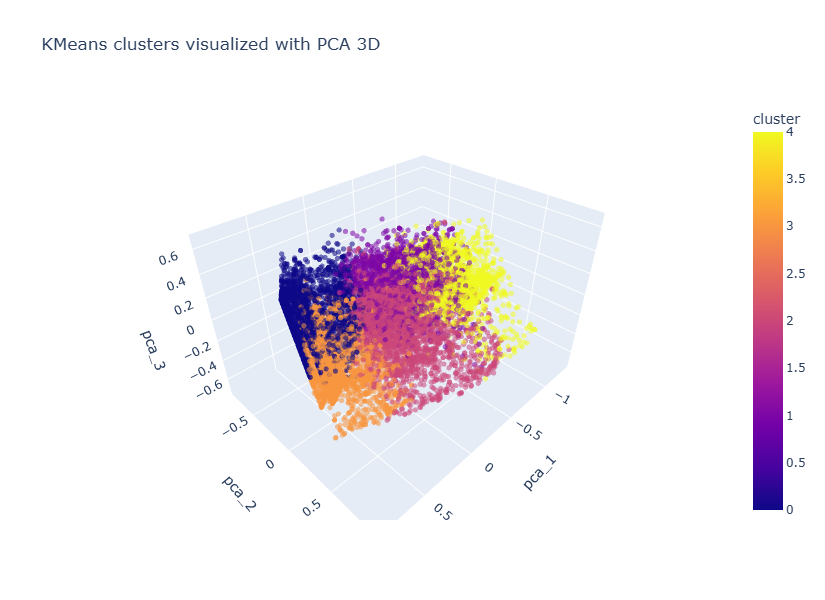

In [24]:
fig = px.scatter_3d(
    pca_3d_df,
    x="pca_1",
    y="pca_2",
    z="pca_3",
    color="cluster",
    hover_data=["ticker", "company_name", "fiscal_year"],
    title="KMeans clusters visualized with PCA 3D",
    opacity=0.55,
)

fig.update_traces(marker=dict(size=3))

fig.update_layout(
    width=800,
    height=600,
)

fig.show()

## 8. Save outputs and model artifact

Artifact schema/persistence lives in `artifacts.py`.

In [25]:
# ---------------------------------------------------------------------
# Save review / reporting outputs
# ---------------------------------------------------------------------
print("\nSaving review outputs...")

cluster_profile_ranked.to_csv(
    CURRENT_OUTPUT_DIR / f"cluster_profile_v3_by_{DEFAULT_SEGMENT_COL}.csv",
    index=False,
)

cluster_profile_ranked_with_reps.to_csv(
    CURRENT_OUTPUT_DIR / f"cluster_profile_with_reps_v3_by_{DEFAULT_SEGMENT_COL}.csv",
    index=False,
)

cluster_medians.to_csv(
    CURRENT_OUTPUT_DIR / f"cluster_medians_v3_by_{DEFAULT_SEGMENT_COL}.csv"
)

feature_extremes.to_csv(
    CURRENT_OUTPUT_DIR / "feature_extremes_v3.csv"
)

industry_cluster_mix.to_csv(
    CURRENT_OUTPUT_DIR / f"industry_cluster_mix_v3_by_{DEFAULT_SEGMENT_COL}.csv",
    index=False,
)

metrics_df.to_csv(
    CURRENT_OUTPUT_DIR / f"cluster_metrics_v3_by_{DEFAULT_SEGMENT_COL}.csv",
    index=False,
)

k_tests.to_csv(
    CURRENT_OUTPUT_DIR / f"cluster_k_tests_v3_by_{DEFAULT_SEGMENT_COL}.csv",
    index=False,
)

print("\nSaved review outputs to:", CURRENT_OUTPUT_DIR)


Saving review outputs...

Saved review outputs to: D:\users\kamen.dimitrov\desktop\SOFTUNI\AI_and_ML_upskill_program\Machine_learning\08_final_project_3\outputs\credit_clustering_outputs_v3


In [26]:
artifact = build_credit_clustering_artifact(
    segment_artifacts=segment_artifacts,
    cluster_profile_ranked=cluster_profile_ranked,
    primary_segment="Non-financial",
    segment_col=DEFAULT_SEGMENT_COL,
    metrics_df=metrics_df,
    cluster_profile=cluster_profile,
    cluster_medians=cluster_medians,
    feature_extremes=feature_extremes,
    industry_cluster_mix=industry_cluster_mix,
    winsor_caps=None,
    artifact_version="v3_scorecard",
    notes=(
        "V3 KMeans++ k=5 model trained on bounded directional credit-risk factors. "
        "Debt-service risk includes EBITDA-enhanced diagnostics where available, "
        "with legacy coverage/FCF fallback when EBITDA is unavailable. "
        "Absolute size is excluded from clustering and retained only as diagnostic flags. "
        "Labels are rating-style interpretations, not formal credit ratings."
    ),
    extra_metadata={
        "model_name": "nonfinancial_credit_scorecard_kmeans_k5",
        "training_rows": int(len(clustered_panel[clustered_panel[DEFAULT_SEGMENT_COL] == "Non-financial"])),
        "source_notebook": "02_credit_clustering.ipynb",
    },
)

saved_path = save_artifact(
    artifact,
    ARTIFACT_PATH,
    segment="Non-financial",
)

print("Saved model artifact to:", saved_path)
summarize_artifact(artifact, segment="Non-financial")

Saved model artifact to: D:\users\kamen.dimitrov\desktop\SOFTUNI\AI_and_ML_upskill_program\Machine_learning\08_final_project_3\outputs\saved_models\nonfinancial_credit_scorecard_kmeans_k5_v3.joblib


{'artifact_version': 'v3_scorecard',
 'primary_segment': 'Non-financial',
 'segment': 'Non-financial',
 'feature_cols': ['earnings_risk',
  'structural_distress_risk',
  'operating_cashflow_risk',
  'liquidity_risk',
  'debt_service_risk',
  'leverage_risk'],
 'n_clusters': 5,
 'cluster_labels': {4: '1 - Strong relative credit profile',
  1: '2 - Good credit profile',
  2: '3 - Leveraged / elevated risk profile',
  0: '4 - Weak credit profile',
  3: '5 - Distressed / near-default proxy'},
 'risk_rank': {4: 1, 1: 2, 2: 3, 0: 4, 3: 5},
 'cluster_sizes': {0: 2714, 1: 2048, 2: 3418, 3: 2354, 4: 1640},
 'silhouette': 0.2633227982622144,
 'calinski_harabasz': 4862.609080423672,
 'davies_bouldin': 1.3252994928493005}

In [27]:
CLUSTERED_PANEL_PATH = (
    CURRENT_OUTPUT_DIR / f"clustered_panel_v3_by_{DEFAULT_SEGMENT_COL}.csv"
)

clustered_panel.to_csv(CLUSTERED_PANEL_PATH, index=False)

print("Saved clustered panel to:", CLUSTERED_PANEL_PATH)

Saved clustered panel to: D:\users\kamen.dimitrov\desktop\SOFTUNI\AI_and_ML_upskill_program\Machine_learning\08_final_project_3\outputs\credit_clustering_outputs_v3\clustered_panel_v3_by_financial_flag.csv


## 9. Handoff to Notebook 03

Notebook 03 should load the saved artifact and use `score_companies()` plus `diagnostics.py` utilities for manual/private-company scoring.